# Memory · strategy comparison

FWI backward passes need access to the full forward wavefield to compute the imaging condition. The three common ways to make that tractable are:

- **Full wavefield (no savings):** store every timestep; fastest but most memory-hungry.
- **Boundary saving:** save a stencil-width strip along each side of the physical interior + last two interior snapshots; replay forward by reverse-time propagation during backward. Cheap memory, ~2× more compute.
- **Checkpointing:** save snapshots at intermediate timesteps; replay forward from the nearest checkpoint when backward needs a missing timestep.
- **Boundary dtype compression (NEW):** ``storage_dtype`` ∈ ``{'fp32', 'fp16', 'bf16', 'int8'}`` reduces boundary buffer size with cast/quantize at storage boundary; compute stays FP32.

This notebook runs **one forward + backward step** of a small acoustic FWI problem under different memory strategies and reports peak GPU memory + wallclock + boundary buffer size. Boundary saving is exercised in **both** back-ends: the compiled ``impl='c'`` path (gpu/cpu/disk storage) and the pure-PyTorch ``impl='eager'`` path (gpu storage), across the fp32/fp16/bf16/int8 dtype matrix.

## 1. Setup — one shot on 25 m Marmousi

In [1]:
import os
import time
import numpy as np
import torch
import matplotlib.pyplot as plt

from sweep.equations import Acoustic
from sweep.propagator.torch import PropTorch
from sweep.signal import ricker
from sweep.datasets import load_marmousi, MARMOUSI_DH

dh, dt, nt = MARMOUSI_DH * 2, 0.002, 2000   # 25 m, 4 s
freq, delay = 5.0, 0.20

vp_true_np = load_marmousi('true')[::2, ::2].copy()
vp_init_np = load_marmousi('smooth')[::2, ::2].copy()
shape = vp_true_np.shape
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device, ' shape:', shape, ' record:', f'{nt*dt:.1f} s')

nshots, nrec = 1, 100
src_x = np.array([shape[1] // 2], dtype=np.int64)
rec_x = np.linspace(0, shape[1] - 1, nrec).astype(np.int64)
sources   = np.stack([src_x, np.full(nshots, 2, dtype=np.int64)], axis=1)
receivers = np.stack([rec_x, np.full(nrec, 4, dtype=np.int64)], axis=1)
receivers = np.repeat(receivers[None, ...], nshots, axis=0)
t = np.arange(nt, dtype=np.float32) * dt
wavelet = ricker(t - delay, f=freq)
vp_true_t = torch.tensor(vp_true_np, device=device)


device: cuda  shape: (141, 681)  record: 4.0 s


## 2. Generate the observed data once

In [2]:
with torch.no_grad():
    eq = Acoustic(device=device)
    solver_obs = PropTorch(eq, shape=shape, dh=dh, dt=dt, nt=nt)
    observed = solver_obs(wavelet, sources, receivers, models=[vp_true_t]).detach()
print('observed:', tuple(observed.shape))
del solver_obs
torch.cuda.empty_cache()


observed: (1, 2000, 100, 1)


### Aside · which sources and receivers does this equation accept?

In [3]:
print('models (input order matters!):')
for spec in eq.MODEL_SPECS:
    unit = f' [{spec.unit}]' if spec.unit else ''
    print(f'  - {spec.name:8s}{unit}  — {spec.description}')
print('defaults  :', eq.default_source_fields, '/', eq.default_receiver_fields)
print('receivers :')
for spec in eq.available_receiver_fields():
    print(f'  - {spec.name:8s} aliases={spec.aliases}  — {spec.description}')


models (input order matters!):
  - vp       [m/s]  — Acoustic P-wave velocity model.
defaults  : ['h1'] / ['h1']
receivers :
  - h1       aliases=('pressure', 'p')  — Primary acoustic pressure-like wavefield.


## 3. The strategies

```
PropTorch
 ├── eager_options : EagerOptions          # eager-only
 └── cuda_options  : CUDAOptions           # c-only memory block
      └── memory   : MemoryOptions         # pick one strategy:
           ├── boundary : BoundaryOptions  # storage / pinning / interval / storage_dtype
           └── ckpt     : CkptOptions      # chunk / recursive
```

In [4]:
import tempfile
from sweep.propagator.options import MemoryOptions, BoundaryOptions, CkptOptions

strategies = []

# --- baselines: full storage + checkpointing ------------------------
strategies.append(('eager · full', dict(impl='eager', use_ckpt=False)))
strategies.append(('eager · chunk-ckpt', dict(impl='eager', use_ckpt=True, ckpt_chunks=100)))
strategies.append(('c · full', dict(impl='c', use_ckpt=False)))

disk_dir = tempfile.mkdtemp(prefix='sweep_bdy_nb_')

def bdy(storage, dtype):
    kw = dict(storage=storage, storage_dtype=dtype)
    if storage in ('cpu', 'disk'):
        kw['transfer_interval'] = 8
    if storage == 'cpu':
        kw['pinned_memory'] = True
    if storage == 'disk':
        kw['disk_dir'] = disk_dir
    return MemoryOptions(strategy='boundary', boundary=BoundaryOptions(**kw))

# --- eager boundary saving (NEW) — gpu only, across dtypes ----------
# The pure-PyTorch path reconstructs by reverse-time marching and keeps the
# ring ON-DEVICE (no cpu/disk staging yet), but storage_dtype still shrinks the
# on-GPU ring 2x (fp16/bf16) / ~4x (int8); the gradient is unchanged.
for dtype in ('fp32', 'fp16', 'bf16', 'int8'):
    strategies.append((f'eager · bdy gpu · {dtype}', dict(impl='eager', memory=bdy('gpu', dtype))))

# --- c boundary storage x dtype matrix ------------------------------
# {gpu, cpu, disk} x {fp32, fp16, bf16, int8}.  storage_dtype casts / quantizes
# only at the storage boundary (compute stays FP32). Where the buffer lives:
#   gpu  -> on-device (shrinks GPU peak directly)
#   cpu  -> pinned host RAM   (only a small transfer ring on GPU)  -- c only
#   disk -> streamed to files (only a small transfer ring on GPU)  -- c only
for storage in ('gpu', 'cpu', 'disk'):
    for dtype in ('fp32', 'fp16', 'bf16', 'int8'):
        strategies.append((f'c · bdy {storage} · {dtype}', dict(impl='c', memory=bdy(storage, dtype))))

# --- checkpointing --------------------------------------------------
strategies.append(('c · chunk-ckpt',
    dict(impl='c', memory=MemoryOptions(strategy='ckpt', ckpt=CkptOptions(mode='chunk', chunks=100)))))
strategies.append(('c · recursive-ckpt',
    dict(impl='c', memory=MemoryOptions(strategy='ckpt', ckpt=CkptOptions(mode='recursive', count=8)))))

for label, _ in strategies:
    print(label)

eager · full
eager · chunk-ckpt
c · full
eager · bdy gpu · fp32
eager · bdy gpu · fp16
eager · bdy gpu · bf16
eager · bdy gpu · int8
c · bdy gpu · fp32
c · bdy gpu · fp16
c · bdy gpu · bf16
c · bdy gpu · int8
c · bdy cpu · fp32
c · bdy cpu · fp16
c · bdy cpu · bf16
c · bdy cpu · int8
c · bdy disk · fp32
c · bdy disk · fp16
c · bdy disk · bf16
c · bdy disk · int8
c · chunk-ckpt
c · recursive-ckpt


## 4. Measure peak memory + wallclock + boundary buffer

One forward + one MSE gradient against the smooth start, for every strategy
including the full `{gpu, cpu, disk} × {fp32, fp16, bf16, int8}` boundary matrix.
Three metrics:

- **total GPU peak** — `cuda.max_memory_allocated`; cpu/disk staging shifts the
  boundary off-device, so they cut this the most.
- **boundary footprint** — the persistent boundary storage *wherever it lives*
  (on-device buffer for `gpu`, host RAM for `cpu`, on-disk files for `disk`);
  this is what `storage_dtype` shrinks 2× (fp16/bf16) or ~4× (int8).
- **wallclock** of the fwd+bwd pass.

``||grad||₂`` is printed too — it stays consistent across dtypes (lossy int8
included), confirming compression doesn't corrupt the gradient.

In [5]:
import sweep.propagator._eager_boundary_saving as _ebs

# Capture the per-rollout ReconState so we can read the eager boundary ring size
# (eager keeps it on-device in a ReconState buffer, not on the solver object).
_seen_recon = []
_orig_recon_init = _ebs.ReconState.__init__
def _recon_hook(self, *a, **k):
    _orig_recon_init(self, *a, **k); _seen_recon.append(self)
_ebs.ReconState.__init__ = _recon_hook


def boundary_breakdown(solver):
    """Where the persistent boundary storage actually lives, in MiB (c path):
      gpu — on-device bytes; cpu — host-RAM bytes; disk — real on-disk file bytes.
    int8 counts both its uint8 main buffer and its FP32 per-256-cell scale."""
    impl = solver._backend_impl

    def tsize(ts):
        return sum(t.element_size() * t.numel() for t in (ts or ())) / 2**20

    gpu = tsize(getattr(impl, 'boundary_gpu_full', ())) + tsize(getattr(impl, 'boundary_gpu', ()))
    cpu = tsize(getattr(impl, 'boundary_cpu', ()))
    files = getattr(impl, '_boundary_disk_files', ()) or ()
    disk = sum(os.path.getsize(f) for f in files) / 2**20
    dtype = 'n/a'
    for ts in (getattr(impl, 'boundary_gpu_full', ()),
               getattr(impl, 'boundary_cpu', ()),
               getattr(impl, 'boundary_gpu', ())):
        if ts:
            dtype = str(ts[0].dtype).replace('torch.', '')
            break
    return dict(gpu=gpu, cpu=cpu, disk=disk, n_files=len(files), dtype=dtype)


def _t_mib(t):
    return t.element_size() * t.numel() / 2**20

def eager_boundary_breakdown(st):
    """Eager ring lives on-device in the ReconState (one buf, or int8 codes+scale)."""
    gpu = (_t_mib(st.codes) + _t_mib(st.scale)) if st.store_dtype == 'int8' else _t_mib(st.buf)
    return dict(gpu=gpu, cpu=0.0, disk=0.0, dtype=st.store_dtype)


def measure(strategy_label, kwargs):
    os.environ.pop('SWEEP_BOUNDARY_DTYPE', None)
    os.environ.pop('SWEEP_FP16_BOUNDARY', None)
    _seen_recon.clear()
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()
    eq = Acoustic(device=device)
    solver = PropTorch(eq, shape=shape, dh=dh, dt=dt, nt=nt, **kwargs)
    vp_p = torch.nn.Parameter(torch.tensor(vp_init_np, device=device))
    torch.cuda.synchronize(); t0 = time.time()
    pred = solver(wavelet, sources, receivers, models=[vp_p])
    loss = (pred - observed).pow(2).mean()
    loss.backward()
    torch.cuda.synchronize()
    dt_s = time.time() - t0
    peak = torch.cuda.max_memory_allocated() / 2**30
    grad_l2 = vp_p.grad.detach().pow(2).mean().sqrt().item()
    mem_opt = kwargs.get('memory')
    is_eager_bdy = kwargs.get('impl') == 'eager' and getattr(mem_opt, 'strategy', None) == 'boundary'
    if is_eager_bdy and _seen_recon:
        bd = eager_boundary_breakdown(_seen_recon[-1])     # read ring straight off the ReconState
    else:
        bd = boundary_breakdown(solver)                    # c path (or no-boundary -> zeros)
    del solver, vp_p, pred, loss
    torch.cuda.empty_cache()
    return dict(label=strategy_label, time_s=dt_s, peak_gb=peak, grad_l2=grad_l2,
                bdy_gpu=bd['gpu'], bdy_cpu=bd['cpu'], bdy_disk=bd['disk'],
                bdy_total=bd['gpu'] + bd['cpu'] + bd['disk'], bdy_dtype=bd['dtype'])

results = []
for label, kw in strategies:
    r = measure(label, kw)
    results.append(r)
    print(f"{r['label']:24s} peak={r['peak_gb']*1024:7.1f}MiB  "
          f"bdy[gpu {r['bdy_gpu']:6.1f} | cpu {r['bdy_cpu']:6.1f} | disk {r['bdy_disk']:6.1f}] MiB "
          f"({r['bdy_dtype']:>7s})  {r['time_s']:5.2f}s  ||g||₂={r['grad_l2']:.2e}")

_ebs.ReconState.__init__ = _orig_recon_init   # restore

eager · full             peak= 5985.3MiB  bdy[gpu    0.0 | cpu    0.0 | disk    0.0] MiB (    n/a)  14.93s  ||g||₂=3.10e-07


eager · chunk-ckpt       peak=  398.1MiB  bdy[gpu    0.0 | cpu    0.0 | disk    0.0] MiB (    n/a)   5.18s  ||g||₂=3.10e-07
c · full                 peak= 1488.7MiB  bdy[gpu    0.0 | cpu    0.0 | disk    0.0] MiB (    n/a)   0.07s  ||g||₂=3.09e-07


eager · bdy gpu · fp32   peak=  157.5MiB  bdy[gpu   31.4 | cpu    0.0 | disk    0.0] MiB (   fp32)  11.72s  ||g||₂=3.10e-07


eager · bdy gpu · fp16   peak=   54.3MiB  bdy[gpu   15.7 | cpu    0.0 | disk    0.0] MiB (   fp16)   6.75s  ||g||₂=3.10e-07


eager · bdy gpu · bf16   peak=   54.3MiB  bdy[gpu   15.7 | cpu    0.0 | disk    0.0] MiB (   bf16)   6.44s  ||g||₂=3.10e-07


...

c · bdy cpu · bf16       peak=   17.1MiB  bdy[gpu    0.1 | cpu   18.8 | disk    0.0] MiB (bfloat16)   0.12s  ||g||₂=3.11e-07


c · bdy cpu · int8       peak=   17.1MiB  bdy[gpu    0.0 | cpu    9.6 | disk    0.0] MiB (  uint8)   0.20s  ||g||₂=3.11e-07
c · bdy disk · fp32      peak=   17.5MiB  bdy[gpu    0.5 | cpu    0.5 | disk   37.6] MiB (float32)   0.18s  ||g||₂=3.11e-07


c · bdy disk · fp16      peak=   17.3MiB  bdy[gpu    0.2 | cpu    0.2 | disk   18.8] MiB (float16)   0.17s  ||g||₂=3.11e-07
c · bdy disk · bf16      peak=   17.3MiB  bdy[gpu    0.2 | cpu    0.2 | disk   18.8] MiB (bfloat16)   0.16s  ||g||₂=3.11e-07


c · bdy disk · int8      peak=   17.2MiB  bdy[gpu    0.1 | cpu    0.1 | disk    9.6] MiB (  uint8)   0.22s  ||g||₂=3.11e-07
c · chunk-ckpt           peak=  182.0MiB  bdy[gpu    0.0 | cpu    0.0 | disk    0.0] MiB (    n/a)   0.10s  ||g||₂=3.09e-07


c · recursive-ckpt       peak=   97.0MiB  bdy[gpu    0.0 | cpu    0.0 | disk    0.0] MiB (    n/a)   0.22s  ||g||₂=3.09e-07


## 5. Visual summary

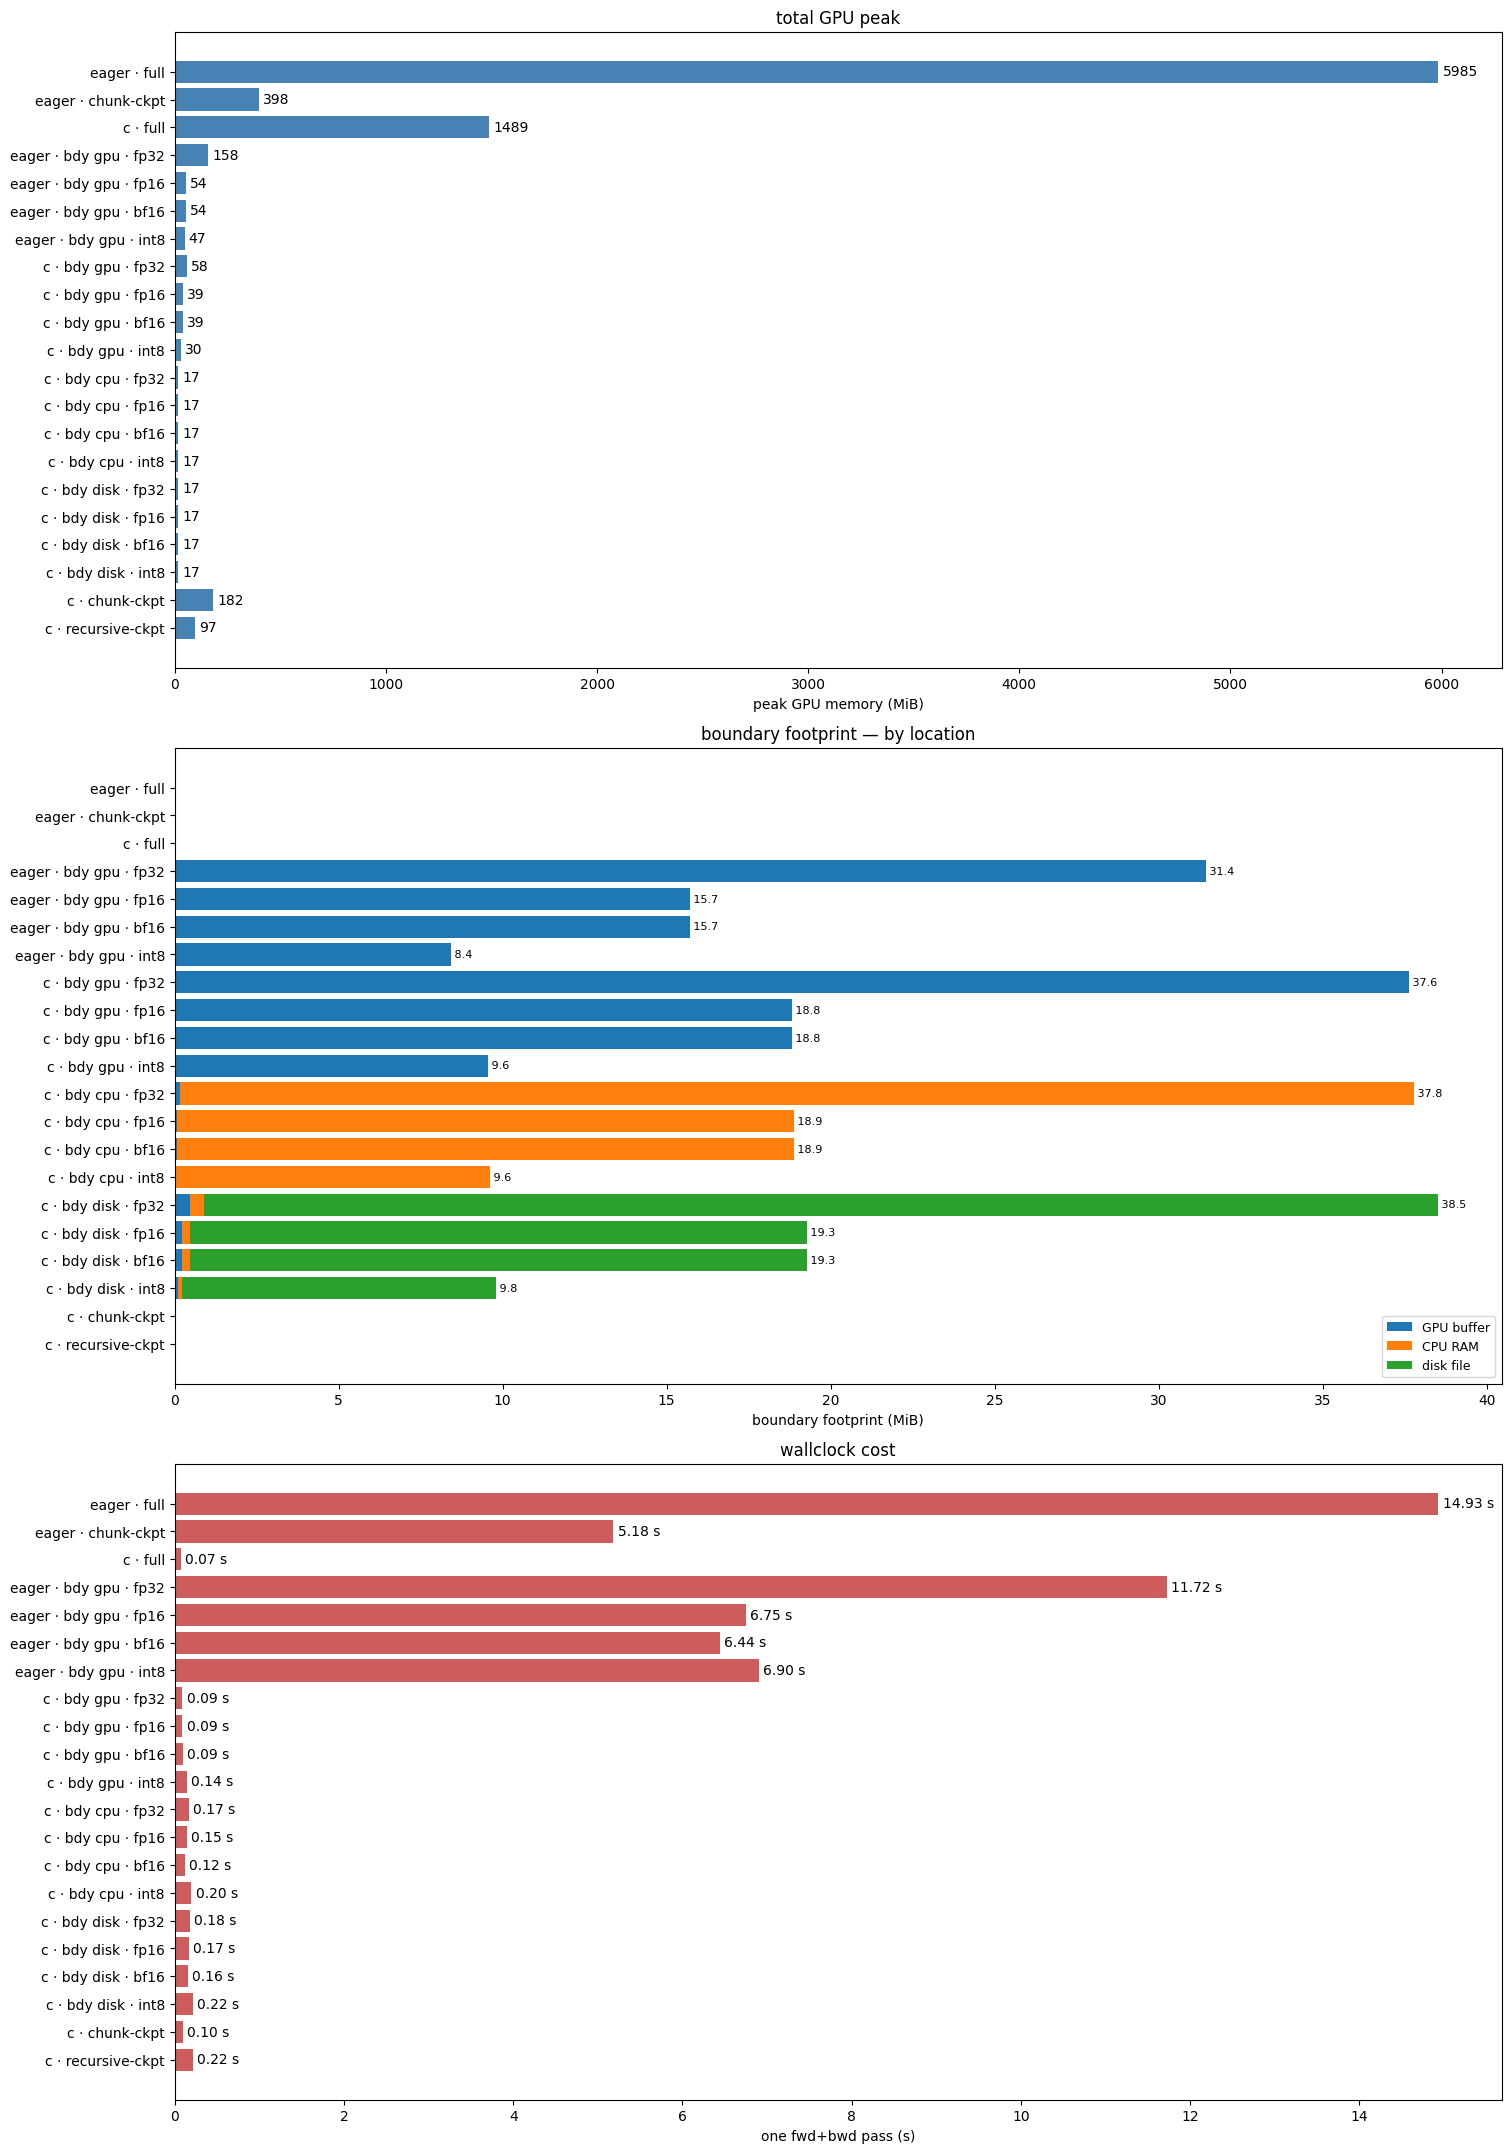

In [6]:
import numpy as np

labels   = [r['label'] for r in results]
peaks    = [r['peak_gb'] * 1024 for r in results]   # GB → MiB
bdy_gpu  = np.array([r['bdy_gpu'] for r in results])
bdy_cpu  = np.array([r['bdy_cpu'] for r in results])
bdy_disk = np.array([r['bdy_disk'] for r in results])
times    = [r['time_s'] for r in results]
y = np.arange(len(labels))

# 3 rows x 1 col, stacked vertically and pulled wide so the long strategy
# labels and bar values are easy to read.
row_h = max(4.0, 0.34 * len(labels))
fig, axes = plt.subplots(3, 1, figsize=(15, 3 * row_h), constrained_layout=True)

bars0 = axes[0].barh(y, peaks, color='steelblue')
axes[0].set_yticks(y); axes[0].set_yticklabels(labels)
axes[0].set_xlabel('peak GPU memory (MiB)')
axes[0].set_title('total GPU peak')
axes[0].bar_label(bars0, fmt='%.0f', padding=3)
axes[0].invert_yaxis()

# Boundary footprint split by where it actually lives.
axes[1].barh(y, bdy_gpu, color='tab:blue', label='GPU buffer')
axes[1].barh(y, bdy_cpu, left=bdy_gpu, color='tab:orange', label='CPU RAM')
axes[1].barh(y, bdy_disk, left=bdy_gpu + bdy_cpu, color='tab:green', label='disk file')
totals = bdy_gpu + bdy_cpu + bdy_disk
for yi, tot in zip(y, totals):
    if tot > 0:
        axes[1].text(tot, yi, f' {tot:.1f}', va='center', fontsize=8)
axes[1].set_yticks(y); axes[1].set_yticklabels(labels)
axes[1].set_xlabel('boundary footprint (MiB)')
axes[1].set_title('boundary footprint — by location')
axes[1].legend(loc='lower right', fontsize=9)
axes[1].invert_yaxis()

bars2 = axes[2].barh(y, times, color='indianred')
axes[2].set_yticks(y); axes[2].set_yticklabels(labels)
axes[2].set_xlabel('one fwd+bwd pass (s)')
axes[2].set_title('wallclock cost')
axes[2].bar_label(bars2, fmt='%.2f s', padding=3)
axes[2].invert_yaxis()
plt.show()
